In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/covid_merged.csv", parse_dates=["date"])
print("Data loaded:", df.shape)

Data loaded: (221904, 23)


In [3]:
!pip install scikit-learn


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.6 MB 9.3 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/36.6 MB 8.4 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/36.6 MB 8.2 MB/s eta 0:00:04
   ------- -------------------------------- 6.6/36.6 MB 8.2 MB/s eta 0:00:04
   -------- ------------------------------- 8.1/36.6 MB 8.1 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/36.6 MB 8.1 MB/s eta 0:00:04
   ------------ --------------------------- 11.5/36.6 MB 8.0 MB/s eta 0:00:04
   -------------- ------------------------- 13.4/36.6 MB 8.0 

In [5]:
def get_country_data(country, min_date="2020-03-01"):
    subset = (
        df[df["country"] == country]
        .copy()
        .sort_values("date")
    )
    subset = subset[subset["date"] >= min_date]
    subset = subset[subset["new_cases_7day"] >= 0].dropna(subset=["new_cases_7day"])
    return subset.reset_index(drop=True)

In [6]:
def run_prophet(country, forecast_days=60, test_days=30):
    data = get_country_data(country)

    # Prophet requires columns named ds and y
    prophet_df = data[["date", "new_cases_7day"]].rename(
        columns={"date": "ds", "new_cases_7day": "y"}
    )

    # Train / test split
    split = len(prophet_df) - test_days
    train = prophet_df.iloc[:split]
    test  = prophet_df.iloc[split:]

    # Fit model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        seasonality_mode="multiplicative"
    )
    model.fit(train)

    # Forecast: test period + future
    future = model.make_future_dataframe(periods=test_days + forecast_days)
    forecast = model.predict(future)

    # Clip negatives (cases can't be negative)
    forecast["yhat"] = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)
    forecast["yhat_upper"] = forecast["yhat_upper"].clip(lower=0)

    # Metrics on test set
    test_forecast = forecast.iloc[split: split + test_days]
    mae  = mean_absolute_error(test["y"].values, test_forecast["yhat"].values)
    rmse = np.sqrt(mean_squared_error(test["y"].values, test_forecast["yhat"].values))

    return model, forecast, train, test, mae, rmse

In [7]:
country = "India"
model, forecast, train, test, mae, rmse = run_prophet(country, forecast_days=60, test_days=30)

print(f"Prophet results for {country}")
print(f"  MAE  : {mae:,.0f} cases/day")
print(f"  RMSE : {rmse:,.0f} cases/day")

01:44:34 - cmdstanpy - INFO - Chain [1] start processing
01:44:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet results for India
  MAE  : 211 cases/day
  RMSE : 224 cases/day


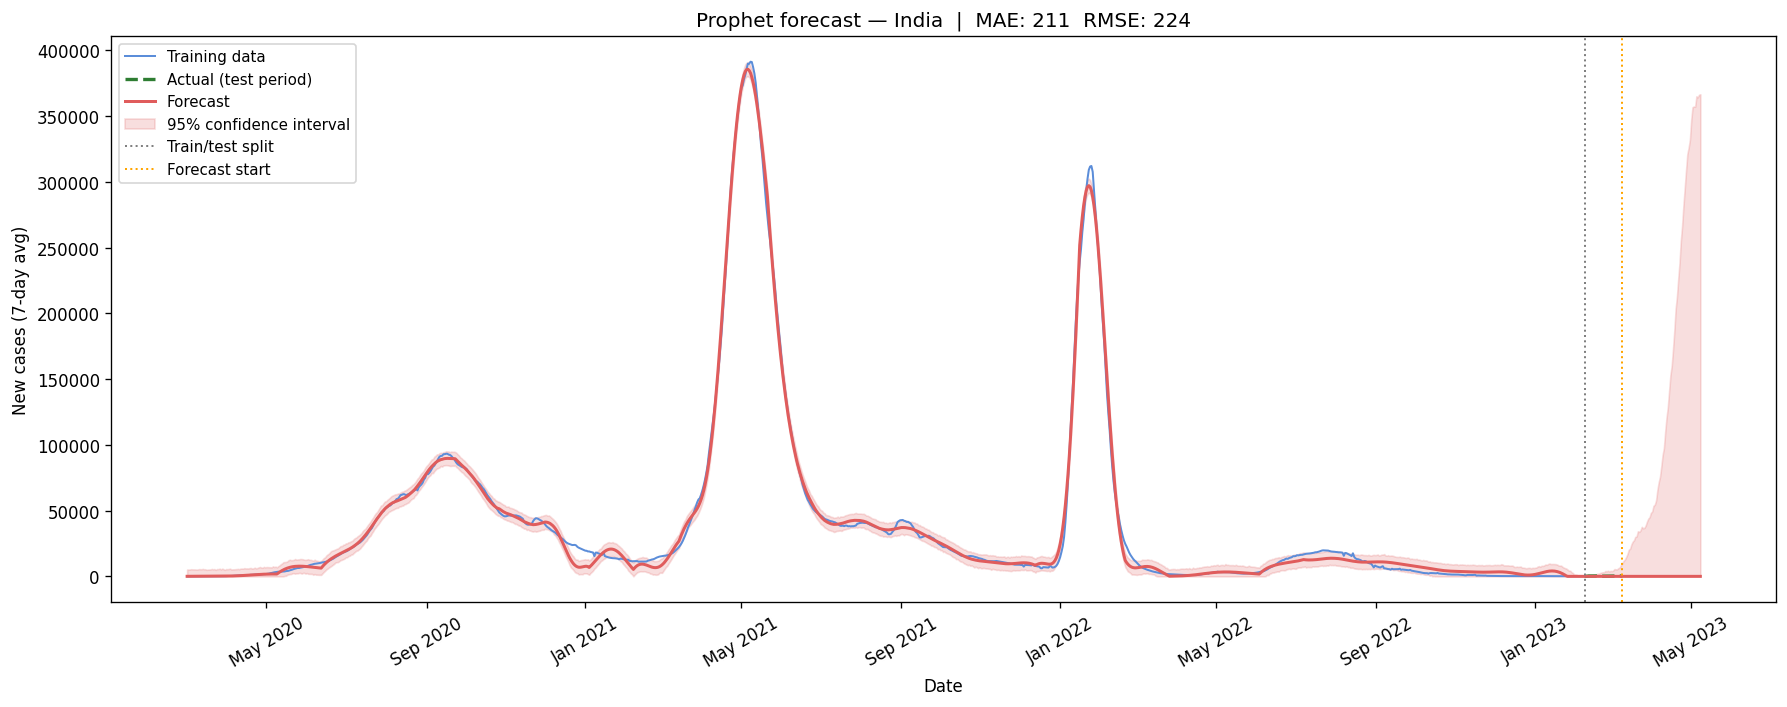

In [8]:
def plot_prophet(country, forecast, train, test, mae, rmse, forecast_days=60):
    split_date = test["ds"].iloc[0]
    future_start = test["ds"].iloc[-1]

    fig, ax = plt.subplots(figsize=(15, 6))

    # Training data
    ax.plot(train["ds"], train["y"], color="#5b8dd9", linewidth=1.2, label="Training data")

    # Actual test data
    ax.plot(test["ds"], test["y"], color="#2e7d32", linewidth=2,
            linestyle="--", label="Actual (test period)")

    # Forecast line
    ax.plot(forecast["ds"], forecast["yhat"], color="#e05c5c",
            linewidth=1.8, label="Forecast")

    # Confidence interval
    ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                    alpha=0.2, color="#e05c5c", label="95% confidence interval")

    # Vertical lines
    ax.axvline(split_date, color="gray", linestyle=":", linewidth=1.2, label="Train/test split")
    ax.axvline(future_start, color="orange", linestyle=":", linewidth=1.2, label="Forecast start")

    ax.set_title(f"Prophet forecast — {country}  |  MAE: {mae:,.0f}  RMSE: {rmse:,.0f}")
    ax.set_xlabel("Date")
    ax.set_ylabel("New cases (7-day avg)")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../data/processed/prophet_{country.lower().replace(' ','_')}.png", dpi=120)
    plt.show()

plot_prophet(country, forecast, train, test, mae, rmse)

In [9]:
from scipy.integrate import odeint

def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I
    return dS, dE, dI, dR

def run_seir(country, forecast_days=60):
    data = get_country_data(country)

    # Use population from dataset
    N = data["population"].dropna().iloc[0]

    # Estimate initial conditions from first wave peak
    I0 = data["new_cases_7day"].iloc[0]
    E0 = I0 * 3        # assume 3x exposed vs infectious
    R0_init = data["confirmed"].iloc[0]
    S0 = N - E0 - I0 - R0_init

    # Epidemiological parameters (COVID-19 estimates)
    beta  = 0.25   # transmission rate
    sigma = 1/5.2  # incubation period ~5.2 days
    gamma = 1/14   # recovery period ~14 days

    t = np.arange(len(data) + forecast_days)
    y0 = S0, E0, I0, R0_init

    solution = odeint(seir_model, y0, t, args=(beta, sigma, gamma, N))
    S, E, I, R = solution.T

    dates = pd.date_range(start=data["date"].iloc[0], periods=len(t))

    seir_df = pd.DataFrame({
        "date": dates,
        "S": S, "E": E, "I": I, "R": R,
        "new_infections": np.maximum(np.diff(R, prepend=R0_init), 0)
    })

    return seir_df, data, N

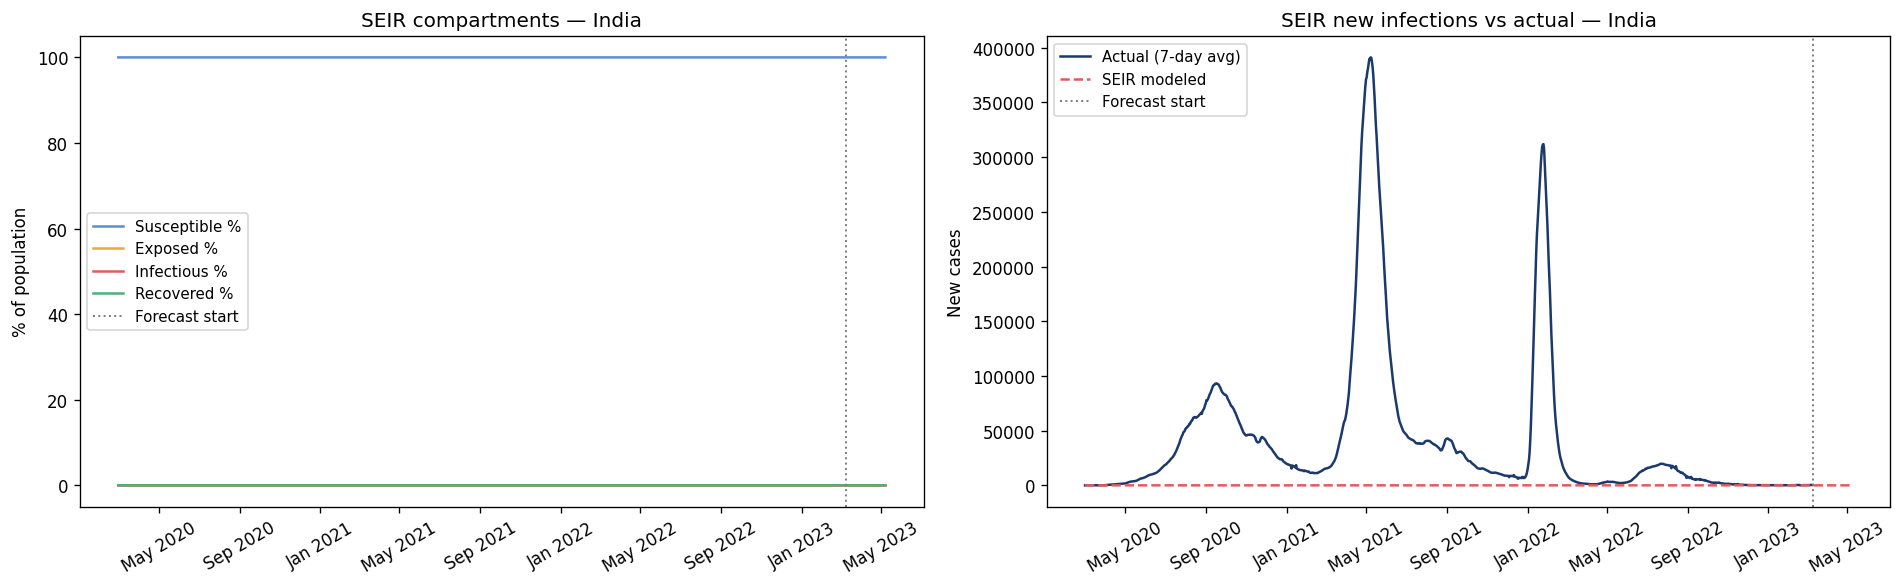

In [10]:
def plot_seir(country, seir_df, actual_data, N):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: SEIR compartments
    ax = axes[0]
    ax.plot(seir_df["date"], seir_df["S"] / N * 100, label="Susceptible %", color="#5b8dd9")
    ax.plot(seir_df["date"], seir_df["E"] / N * 100, label="Exposed %",     color="#f0a830")
    ax.plot(seir_df["date"], seir_df["I"] / N * 100, label="Infectious %",  color="#e05c5c")
    ax.plot(seir_df["date"], seir_df["R"] / N * 100, label="Recovered %",   color="#4caf7d")
    ax.axvline(actual_data["date"].iloc[-1], color="gray",
               linestyle=":", linewidth=1.2, label="Forecast start")
    ax.set_title(f"SEIR compartments — {country}")
    ax.set_ylabel("% of population")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    # Right: SEIR new infections vs actual
    ax2 = axes[1]
    ax2.plot(actual_data["date"], actual_data["new_cases_7day"],
             color="#1a3a6e", linewidth=1.5, label="Actual (7-day avg)")
    ax2.plot(seir_df["date"], seir_df["new_infections"],
             color="#e05c5c", linewidth=1.5, linestyle="--", label="SEIR modeled")
    ax2.axvline(actual_data["date"].iloc[-1], color="gray",
                linestyle=":", linewidth=1.2, label="Forecast start")
    ax2.set_title(f"SEIR new infections vs actual — {country}")
    ax2.set_ylabel("New cases")
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.savefig(f"../data/processed/seir_{country.lower().replace(' ','_')}.png", dpi=120)
    plt.show()

seir_df, actual_data, N = run_seir(country, forecast_days=60)
plot_seir(country, seir_df, actual_data, N)

In [11]:
countries = ["US", "India", "Brazil", "United Kingdom", "Germany"]
results = []

for c in countries:
    try:
        _, forecast, train, test, mae, rmse = run_prophet(c, forecast_days=60, test_days=30)
        results.append({"country": c, "MAE": round(mae), "RMSE": round(rmse)})
        print(f"{c:20s} → MAE: {mae:>10,.0f}  |  RMSE: {rmse:>10,.0f}")
    except Exception as e:
        print(f"{c:20s} → Error: {e}")

results_df = pd.DataFrame(results)
results_df.to_csv("../data/processed/model_results.csv", index=False)
print("\nSaved model results.")

01:45:43 - cmdstanpy - INFO - Chain [1] start processing
01:45:44 - cmdstanpy - INFO - Chain [1] done processing
01:45:45 - cmdstanpy - INFO - Chain [1] start processing


US                   → MAE:     34,720  |  RMSE:     34,875


01:45:46 - cmdstanpy - INFO - Chain [1] done processing
01:45:46 - cmdstanpy - INFO - Chain [1] start processing


India                → MAE:        211  |  RMSE:        224


01:45:47 - cmdstanpy - INFO - Chain [1] done processing
01:45:48 - cmdstanpy - INFO - Chain [1] start processing


Brazil               → MAE:      7,292  |  RMSE:      7,643


01:45:48 - cmdstanpy - INFO - Chain [1] done processing
01:45:49 - cmdstanpy - INFO - Chain [1] start processing


United Kingdom       → MAE:      3,226  |  RMSE:      3,349


01:45:49 - cmdstanpy - INFO - Chain [1] done processing


Germany              → MAE:     11,080  |  RMSE:     12,065

Saved model results.
